# SPR-05 — xAI / SHAP

**Ticket:** SPR-05
**Owner:** Sakhiur
**Depends on:** SPR-03 (trained models, read-only)
**Folder:** `notebooks/05_explainability/`
**Output:** SHAP values saved to `results/shap/`

**Inspiration:** `XAI_Occupational_Stress.ipynb` cell 40. That notebook used `shap.KernelExplainer` wrapped around an SVC, which is model-agnostic but slow. Here we use `shap.TreeExplainer` for the tree-based models (Random Forest, XGBoost, Decision Tree), which is exact and dramatically faster, important given the earlier Colab free-tier stall on an unconstrained RF. `KernelExplainer` is kept only as a fallback for the logistic regression / voting ensemble, on a small background sample.

## 0. Hugging Face setup: login and download data/models
Run this once per Colab session. It authenticates against the `Sakhiur/signal` repo and pulls the CSVs used below. Add your token in Colab's left sidebar (key icon) under the name `HF_TOKEN` before running this cell.

In [1]:
!pip install -q huggingface_hub

import os
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

REPO_ID = 'Sakhiur/signal'

os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

hf_files = {
    'X_test_Sakhiur.csv': 'data/interim/X_test.csv',
    'X_train_resampled_Sakhiur.csv': 'data/interim/X_train_resampled.csv',
    'y_test_Sakhiur.csv': 'data/interim/y_test.csv',
    'y_train_resampled_Sakhiur.csv': 'data/interim/y_train_resampled.csv',
}

for repo_filename, local_path in hf_files.items():
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type='dataset',
        filename=repo_filename,
    )
    import shutil
    shutil.copy(downloaded, local_path)
    print(f'{repo_filename} -> {local_path}')

print('All data files ready.')

X_test_Sakhiur.csv -> data/interim/X_test.csv
X_train_resampled_Sakhiur.csv -> data/interim/X_train_resampled.csv
y_test_Sakhiur.csv -> data/interim/y_test.csv
y_train_resampled_Sakhiur.csv -> data/interim/y_train_resampled.csv
All data files ready.


In [2]:
from huggingface_hub import snapshot_download

models_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type='dataset',
    allow_patterns='models/*',
    local_dir='.',
)
print('Models downloaded to ./models/')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Models downloaded to ./models/


## 1. Install SHAP and load model + data (read-only)

In [3]:
!pip install shap -q

In [4]:
!pip install catboost -q

In [1]:
!pip install lightGBM -q

In [8]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
import numpy as np

class FlattenPredict(ClassifierMixin, BaseEstimator):
    """Wrapper that forces CatBoost.predict() to return a 1-D array."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y, **fit_params):
        self.estimator_ = clone(self.estimator).fit(X, y, **fit_params)
        self.classes_ = self.estimator_.classes_
        self.n_features_in_ = getattr(self.estimator_, "n_features_in_", None)
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self

    def predict(self, X):
        return np.asarray(self.estimator_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)

In [11]:
import pandas as pd
import numpy as np
import joblib
import shap
import os
import matplotlib.pyplot as plt

os.makedirs('results/shap', exist_ok=True)

X_train = pd.read_csv('data/interim/X_train_resampled.csv')
X_test = pd.read_csv('data/interim/X_test.csv')
y_test = pd.read_csv('data/interim/y_test.csv').iloc[:, 0]

# Use the best model per SPR-03's saved comparison table
comparison = pd.read_csv('model_comparison.csv')
print(comparison)

# TODO: confirm this points at the RF/XGBoost model, TreeExplainer needs a tree model
# Best single model per SPR-03 comparison: CatBoostClassifier (macro F1 = 0.599)
model = joblib.load('models/catboost/model.joblib')

                                 model  macro_f1
0                   CatBoostClassifier  0.598993
1  Ensemble Model (Soft Voting, Top 3)  0.598436
2  Ensemble Model (Hard Voting, Top 3)  0.597489
3                        XGBClassifier  0.596848
4                       LGBMClassifier  0.594584
5               DecisionTreeClassifier  0.574914
6               RandomForestClassifier  0.567391
7                   LogisticRegression  0.563971


## 2. TreeExplainer on the depth-capped Random Forest
Fast and exact for tree ensembles. This is the fix for the earlier SHAP stall, which happened on an unconstrained RF; this model is already depth-capped from SPR-03 (`max_depth=10`).

In [12]:
explainer = shap.TreeExplainer(model)

# Use a manageable sample of the test set to keep this within Colab free-tier limits
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

print('SHAP values shape (per class):')
if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f'Class {i}: {sv.shape}')
else:
    print(shap_values.shape)

SHAP values shape (per class):
(500, 25, 4)


## 3. Summary plot (global feature importance)
For multi-class output, plot each class separately so the story is clear per income tier (No_income / Lower / Middle / Upper), not collapsed into one ambiguous chart.

<Figure size 640x480 with 0 Axes>

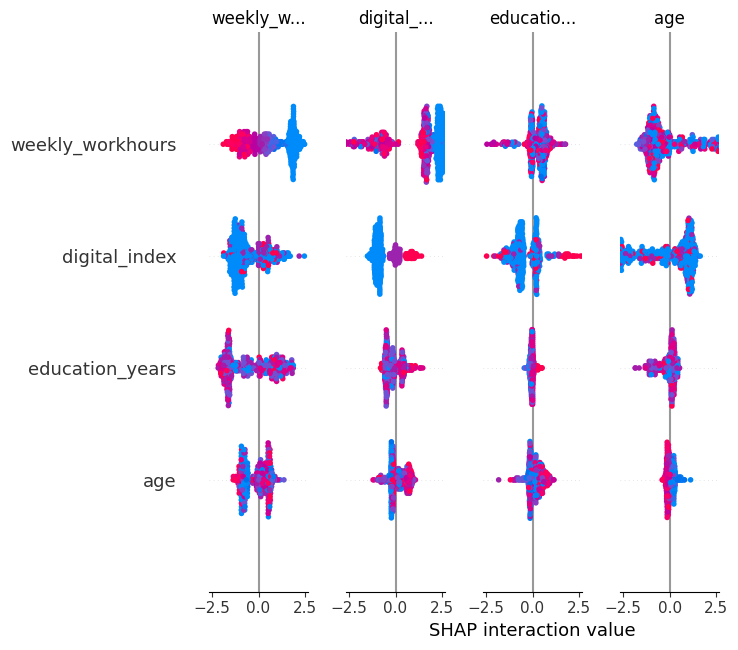

In [13]:
class_names = sorted(y_test.unique().tolist())

if isinstance(shap_values, list):
    for i, class_name in enumerate(class_names):
        plt.figure()
        shap.summary_plot(shap_values[i], X_sample, show=False)
        plt.title(f'SHAP Summary: {class_name}')
        plt.tight_layout()
        plt.savefig(f'results/shap/summary_{class_name}.png', dpi=200, bbox_inches='tight')
        plt.show()
        plt.close()
else:
    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig('results/shap/summary.png', dpi=200, bbox_inches='tight')
    plt.show()

## 4. Dependence plot: digital_index
This is the core research variable. A dependence plot shows how digital_index's SHAP value changes across its own range, and optionally colors by an interaction feature (e.g. education_years), which previews SPR-07's interaction analysis.

sv_for_plot shape: (500, 25)


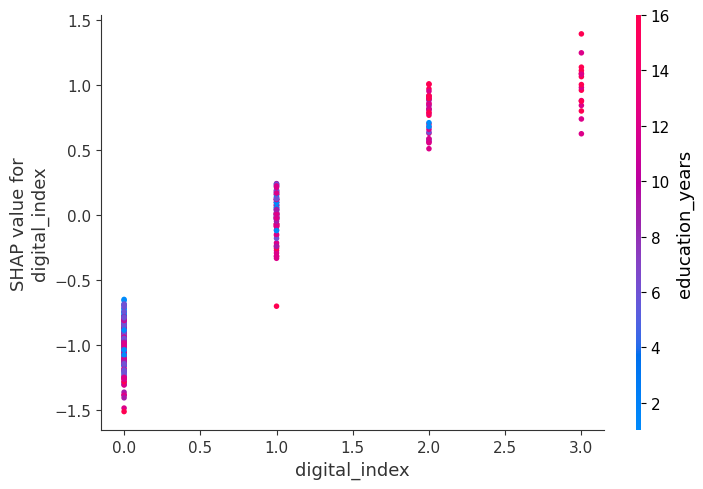

In [15]:
target_class_idx = 3  # index of 'Upper' income class per class_names above

# LightGBM's TreeExplainer here returns shape (samples, features, classes),
# not a list of per-class arrays like CatBoost did, so slice the last axis
if isinstance(shap_values, list):
    sv_for_plot = shap_values[target_class_idx]
else:
    sv_for_plot = shap_values[:, :, target_class_idx]

print('sv_for_plot shape:', sv_for_plot.shape)  # should be (500, 25), matching X_sample

shap.dependence_plot(
    'digital_index', sv_for_plot, X_sample,
    interaction_index='education_years',
    show=False
)
plt.tight_layout()
plt.savefig('results/shap/dependence_digital_index.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Save raw SHAP values for downstream use
SPR-06 (subgroup analysis) reads this file directly. Saved as a compressed numpy archive since multi-class SHAP arrays don't fit cleanly into a flat CSV.

In [16]:
if isinstance(shap_values, list):
    np.savez_compressed(
        'results/shap/shap_values.npz',
        **{f'class_{name}': shap_values[i] for i, name in enumerate(class_names)}
    )
else:
    np.savez_compressed('results/shap/shap_values.npz', values=shap_values)

X_sample.to_csv('results/shap/shap_sample_features.csv', index=False)
print('Saved SHAP values and matching feature sample for SPR-06 to consume.')

Saved SHAP values and matching feature sample for SPR-06 to consume.


## 6. (Fallback) KernelExplainer for non-tree models
Only run this cell if you also need to explain the logistic regression or voting ensemble. Slower, so keep the background and sample sizes small. This mirrors the pattern from `XAI_Occupational_Stress.ipynb`, adapted with a small `shap.sample` background instead of the full training set, which is what made the original approach slow.

In [ ]:
# lr_model = joblib.load('models/logistic_regression/model.joblib')
# background = shap.sample(X_train, 100, random_state=42)
# kernel_explainer = shap.KernelExplainer(lr_model.predict_proba, background)
# kernel_shap_values = kernel_explainer.shap_values(X_test.sample(50, random_state=42))
# shap.summary_plot(kernel_shap_values, X_test.sample(50, random_state=42))

In [17]:
!zip -r results.zip results/

  adding: results/ (stored 0%)
  adding: results/shap/ (stored 0%)
  adding: results/shap/shap_values.npz (deflated 0%)
  adding: results/shap/shap_sample_features.csv (deflated 89%)
  adding: results/shap/dependence_digital_index.png (deflated 13%)
  adding: results/shap/summary.png (deflated 4%)
